<a href="https://colab.research.google.com/github/asad-iqbal78/ai-internship/blob/main/week_4_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].copy()

y = df["Survived"]


In [3]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


In [4]:
X["Age"] = X["Age"].fillna(X["Age"].median())

In [5]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0


In [6]:
X["Sex"] = X["Sex"].map({
    "male": 0,
    "female": 1
})

In [7]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)
print("Decision Tree Accuracy", tree_accuracy)
print("Decision Tree Accuracy", tree_accuracy * 100, "%")

Decision Tree Accuracy 0.7597765363128491
Decision Tree Accuracy 75.97765363128491 %


In [10]:
tree_train_pred = tree_model.predict(X_train)

tree_train_accuracy = accuracy_score(
    y_train,
    tree_train_pred
)

print("Training Accuracy:", tree_train_accuracy)
print("Test Accuracy:", tree_accuracy)

Training Accuracy: 0.9789325842696629
Test Accuracy: 0.7597765363128491


In [11]:
from sklearn.metrics import confusion_matrix

tree_cm = confusion_matrix(y_test, tree_pred)

print(tree_cm)

[[84 21]
 [22 52]]


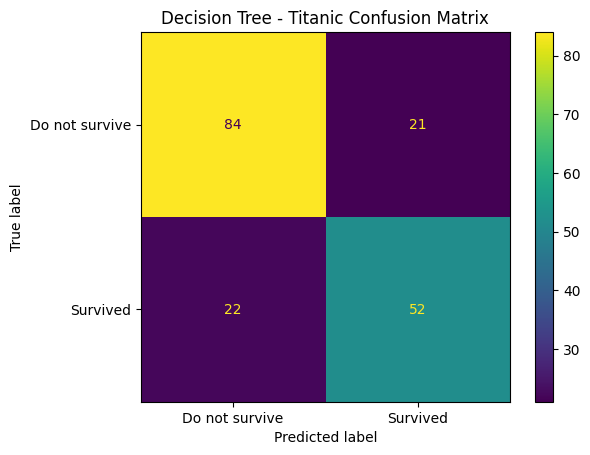

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=["Do not survive", "Survived"]
)

disp.plot()

plt.title("Decision Tree - Titanic Confusion Matrix")
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)


In [15]:
forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
forest_pred = forest_model.predict(X_test)

In [17]:
forest_accuracy = accuracy_score(y_test, forest_pred)
print("Random Forest Accuracy", forest_accuracy)
print("Random Forest Accuracy", forest_accuracy * 100, "%")

Random Forest Accuracy 0.8044692737430168
Random Forest Accuracy 80.44692737430168 %


In [18]:
forest_train_pred = forest_model.predict(X_train)

forest_train_accuracy = accuracy_score(
    y_train,
    forest_train_pred
)

print("Training Accuracy:", forest_train_accuracy)
print("Test Accuracy:", forest_accuracy)

Training Accuracy: 0.9789325842696629
Test Accuracy: 0.8044692737430168


In [19]:
from sklearn.model_selection import cross_val_score

In [20]:
tree_cv = DecisionTreeClassifier(
    random_state = 42
)

tree_scores = cross_val_score(
    tree_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree CV Scores:", tree_scores)
print("Decision Tree CV Average:", tree_scores.mean())
print("Decision Tree CV Average %:", tree_scores.mean() * 100)

Decision Tree CV Scores: [0.74301676 0.78089888 0.80898876 0.76404494 0.82022472]
Decision Tree CV Average: 0.7834348126294646
Decision Tree CV Average %: 78.34348126294645


In [21]:
forest_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_scores = cross_val_score(
    forest_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", forest_scores)
print("Random Forest CV Average:", forest_scores.mean())
print("Random Forest CV Average %:", forest_scores.mean() * 100)

Random Forest CV Scores: [0.76536313 0.82022472 0.87640449 0.7752809  0.83707865]
Random Forest CV Average: 0.8148703785073128
Random Forest CV Average %: 81.48703785073128


In [22]:
from sklearn.linear_model import LogisticRegression

logistic_cv = LogisticRegression(max_iter=1000)

logistic_scores = cross_val_score(
    logistic_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:", logistic_scores)
print("Logistic Regression CV Average:", logistic_scores.mean())
print("Logistic Regression CV Average %:", logistic_scores.mean() * 100)

Logistic Regression CV Scores: [0.7877095  0.7752809  0.78089888 0.75842697 0.82022472]
Logistic Regression CV Average: 0.7845081915761722
Logistic Regression CV Average %: 78.45081915761722


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_logistic = LogisticRegression(max_iter=1000)

scaled_logistic.fit(
    X_train_scaled,
    y_train
)

scaled_logistic_cv = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

scaled_pred = scaled_logistic.predict(X_test_scaled)

scaled_accuracy = accuracy_score(
    y_test,
    scaled_pred
)

scaled_scores = cross_val_score(
    scaled_logistic_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scaled Logistic Regression CV Scores:", scaled_scores)
print(
    "Scaled Logistic Regression CV Average:",
    scaled_scores.mean()
)
print(
    "Scaled Logistic Regression CV Average %:",
    scaled_scores.mean() * 100
)

print("Scaled Logistic Regression Accuracy:", scaled_accuracy)
print(
    "Scaled Logistic Regression Accuracy:",
    scaled_accuracy * 100,
    "%"
)

Scaled Logistic Regression CV Scores: [0.7877095  0.7752809  0.78089888 0.75842697 0.8258427 ]
Scaled Logistic Regression CV Average: 0.7856317870817903
Scaled Logistic Regression CV Average %: 78.56317870817902
Scaled Logistic Regression Accuracy: 0.7988826815642458
Scaled Logistic Regression Accuracy: 79.88826815642457 %


In [24]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Scaled Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Training Accuracy (%)": [
        None,
        None,
        tree_train_accuracy * 100,
        forest_train_accuracy * 100
    ],
    "Test Accuracy (%)": [
        81.0056,
        scaled_accuracy * 100,
        tree_accuracy * 100,
        forest_accuracy * 100
    ],
    "CV Average (%)": [
        logistic_scores.mean() * 100,
        scaled_scores.mean() * 100,
        tree_scores.mean() * 100,
        forest_scores.mean() * 100
    ]
})

final_results.round(2)

,Model,Training Accuracy (%),Test Accuracy (%),CV Average (%)
0,Logistic Regression,NaN,81.01,78.45
1,Scaled Logistic Regression,NaN,79.89,78.56
2,Decision Tree,97.89,75.98,78.34
3,Random Forest,97.89,80.45,81.49


## Week 4 — Model Comparison Conclusion

I compared Logistic Regression, Decision Tree, and Random Forest on the Titanic survival dataset.

The Decision Tree achieved 97.89% training accuracy but only 75.98% test accuracy, which indicates overfitting. Its 5-fold cross-validation average was 78.34%.

Random Forest achieved 97.89% training accuracy and 80.45% test accuracy. Its 5-fold cross-validation average was 81.49%, which was the highest among the models tested.

Logistic Regression achieved 81.01% test accuracy and a 5-fold cross-validation average of 78.45%. After feature scaling, its test accuracy was 79.89% and its cross-validation average was 78.56%.

Based on the cross-validation results, Random Forest performed best on this dataset. Cross-validation also provided a more reliable estimate of model performance than relying on a single train/test split.

The results also showed that feature scaling did not produce a significant improvement for Logistic Regression on this dataset. Decision Trees and Random Forests generally do not require feature scaling.

Overall, Random Forest was the best-performing model among the models I tested, although the difference between training and test accuracy shows that some overfitting remains.
